### Time Series Econometrics - HW 1

## Setup

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR, SVAR


np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 4)


# Assignment 1 — Univariate AR models

## 1.1 A stable AR(1)

$$y_t = a_1 y_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim N(0,\sigma^2)$$

An AR(1) is stable whenever $|a_1| < 1$: the influence of a shock decays
geometrically instead of accumulating. Let's pick $a_1 = 0.5$

In [39]:
# True DGP 
T = 200
a1_true = 0.5
sigma = 1.0

eps = np.random.normal(0, sigma, T)
y_ar1 = np.zeros(T)
y_ar1[0] = eps[0]

# Recursive simulation
for t in range(1, T):
    y_ar1[t] = a1_true * y_ar1[t - 1] + eps[t]


## 1.2 Check stability and visualize

a1 = 0.5,  |a1| < 1 -> stable: True


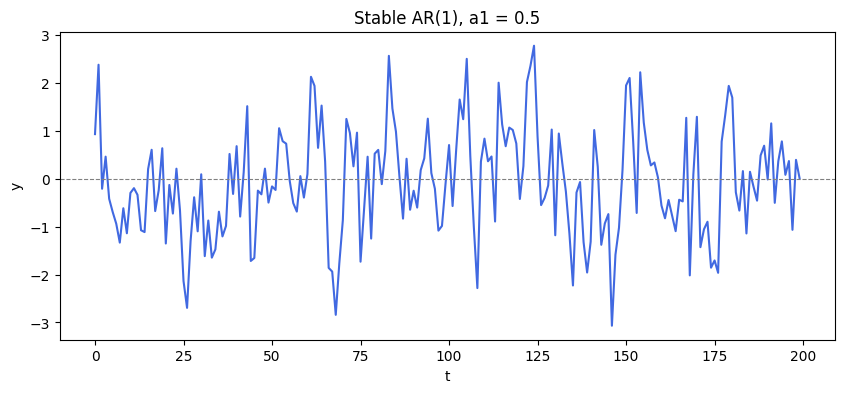

In [40]:
is_stable = abs(a1_true) < 1
print(f"a1 = {a1_true},  |a1| < 1 -> stable: {is_stable}")

plt.plot(y_ar1, color='royalblue')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.title(f'Stable AR(1), a1 = {a1_true}')
plt.xlabel('t')
plt.ylabel('y')
plt.show()


The series fluctuates around a constant mean with a roughly constant amplitude. There is no drift and no explosive growth in the swings.

## 1.3 Estimate AR(1) and discuss the results

In [41]:
ar1_model = AutoReg(y_ar1, lags=1).fit()
print(ar1_model.summary())

a1_hat = np.asarray(ar1_model.params)[1]
print(f"\nTrue a1     = {a1_true}")
print(f"Estimated a1 = {a1_hat:.4f}")
print(f"Estimation error = {a1_hat - a1_true:.4f}")


                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  200
Model:                     AutoReg(1)   Log Likelihood                -281.227
Method:               Conditional MLE   S.D. of innovations              0.994
Date:                Sat, 19 Sep 2026   AIC                            568.454
Time:                        09:41:10   BIC                            578.334
Sample:                             1   HQIC                           572.452
                                  200                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0546      0.071     -0.771      0.440      -0.193       0.084
y.L1           0.4557      0.063      7.240      0.000       0.332       0.579
                                    Roots           

For a correctly specified, stationary AR(1) the  estimator used by  is consistent so with $T=200$ observations the estimated coefficient should sit close to the true value of 0.5. Any gap between the true and estimated value here is just sampling noise from the particular draw of $\varepsilon_t$ - re-running the simulation with a different seed will shrink or grow it randomly, but on average it vanishes as $T \to \infty$.

## 1.4 An unstable, fluctuating AR(2)

$$y_t = a_1 y_{t-1} + a_2 y_{t-2} + \varepsilon_t$$

The qualitative behaviour of an AR(2) is depends by the roots of the characteristic equation
$\alpha^2 - a_1 \alpha - a_2 = 0$:

* modulus of the roots $> 1$ then the process is explosive.

Combining the two gives an unstable, fluctuating series. We use $a_1 = 1.6,\ a_2 = -1.1$.

In [42]:
a1_ar2, a2_ar2 = 1.6, -1.1

roots = np.roots([1, -a1_ar2, -a2_ar2])
d = a1_ar2**2 + 4 * a2_ar2

print(f"Discriminant d = {d:.4f}")
print(f"Roots: {roots}")
print(f"Moduli |root|: {np.abs(roots)}")


Discriminant d = -1.8400
Roots: [0.8+0.678233j 0.8-0.678233j]
Moduli |root|: [1.04880885 1.04880885]


## 1.5 Visualize

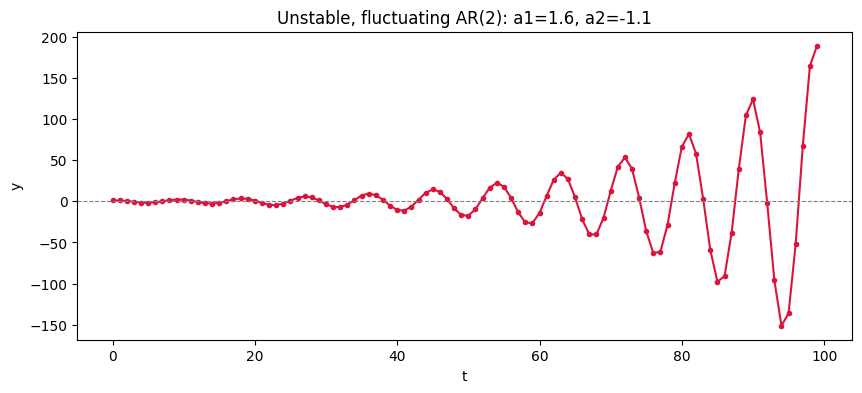

In [43]:
T2 = 100
eps2 = np.random.normal(0, 0.1, T2)
y_ar2 = np.zeros(T2)
y_ar2[0], y_ar2[1] = 1.0, 1.0

for t in range(2, T2):
    y_ar2[t] = a1_ar2 * y_ar2[t - 1] + a2_ar2 * y_ar2[t - 2] + eps2[t]

plt.plot(y_ar2, color='crimson', marker='o', ms=3)
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.title(f'Unstable, fluctuating AR(2): a1={a1_ar2}, a2={a2_ar2}')
plt.xlabel('t')
plt.ylabel('y')
plt.show()


The complex roots produce oscillation, while the modulus above 1 means each swing is larger than the last - an explosively growing cycle rather than a stable one.

## 1.6 Estimate AR(2) and discuss the results

In [44]:
ar2_model = AutoReg(y_ar2, lags=2).fit()
print(ar2_model.summary())

ar2_params = np.asarray(ar2_model.params)
a1_hat2, a2_hat2 = ar2_params[1], ar2_params[2]
print(f"\nTrue (a1, a2)      = ({a1_ar2}, {a2_ar2})")
print(f"Estimated (a1, a2) = ({a1_hat2:.4f}, {a2_hat2:.4f})")


                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  100
Model:                     AutoReg(2)   Log Likelihood                  89.542
Method:               Conditional MLE   S.D. of innovations              0.097
Date:                Sat, 19 Sep 2026   AIC                           -171.083
Time:                        09:41:48   BIC                           -160.744
Sample:                             2   HQIC                          -166.901
                                  100                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0016      0.010     -0.160      0.873      -0.021       0.018
y.L1           1.6001      0.000   4789.301      0.000       1.599       1.601
y.L2          -1.1002      0.000  -3039.807      0.0

Thus the coefficient are close to true values, the results of regression: std err, t statistics will be inconsistend 

# Assignment 2 — VAR(1)

## 2.1 Build a stable VAR(1) system

$$x_t = A x_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim N(0, \Sigma)$$

A VAR(1) is stable when every eigenvalue of $A$ has modulus below 1.

In [47]:
A_var = np.array([[0.5, 0.2],
                   [0.1, 0.4]])

eigvals = np.linalg.eig(A_var)[0]
print("A =\n", A_var)
print(f"\nEigenvalues: {eigvals}")

A =
 [[0.5 0.2]
 [0.1 0.4]]

Eigenvalues: [0.6 0.3]


## 2.2 Simulate the dataset

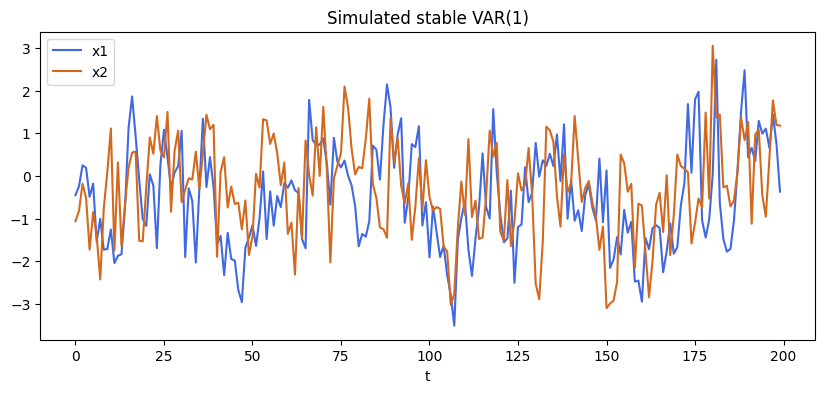

In [48]:
T = 200
mean = [0, 0]
cov = [[1.0, 0.3],
       [0.3, 1.0]]        

eps = np.random.multivariate_normal(mean, cov, T)
x_var = np.zeros((T, 2))
x_var[0] = eps[0]

for t in range(1, T):
    x_var[t] = A_var @ x_var[t - 1] + eps[t]

plt.plot(x_var[:, 0], label='x1', color='royalblue')
plt.plot(x_var[:, 1], label='x2', color='chocolate')
plt.title('Simulated stable VAR(1)')
plt.xlabel('t')
plt.legend()
plt.show()


## 2.3 Estimate the VAR model and report the results

In [54]:
var_model = VAR(x_var)
var_res = var_model.fit(1)         
print(var_res.summary())

print("\nTrue A =\n", A_var)
print("Estimated coefficient matrix =\n", var_res.coefs[0])


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 19, Sep, 2026
Time:                     09:56:47
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                -0.00607589
Nobs:                     199.000    HQIC:                -0.0651840
Log likelihood:          -548.253    FPE:                   0.899994
AIC:                    -0.105372    Det(Omega_mle):        0.873460
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.186509         0.073355           -2.543           0.011
L1.y1         0.547175         0.059882            9.137           0.000
L1.y2         0.152707         0.062392            2.448           0.014

Results for equation 

The estimated coefficient matrix should be close to the true `A`

## 2.4 Impulse-response function

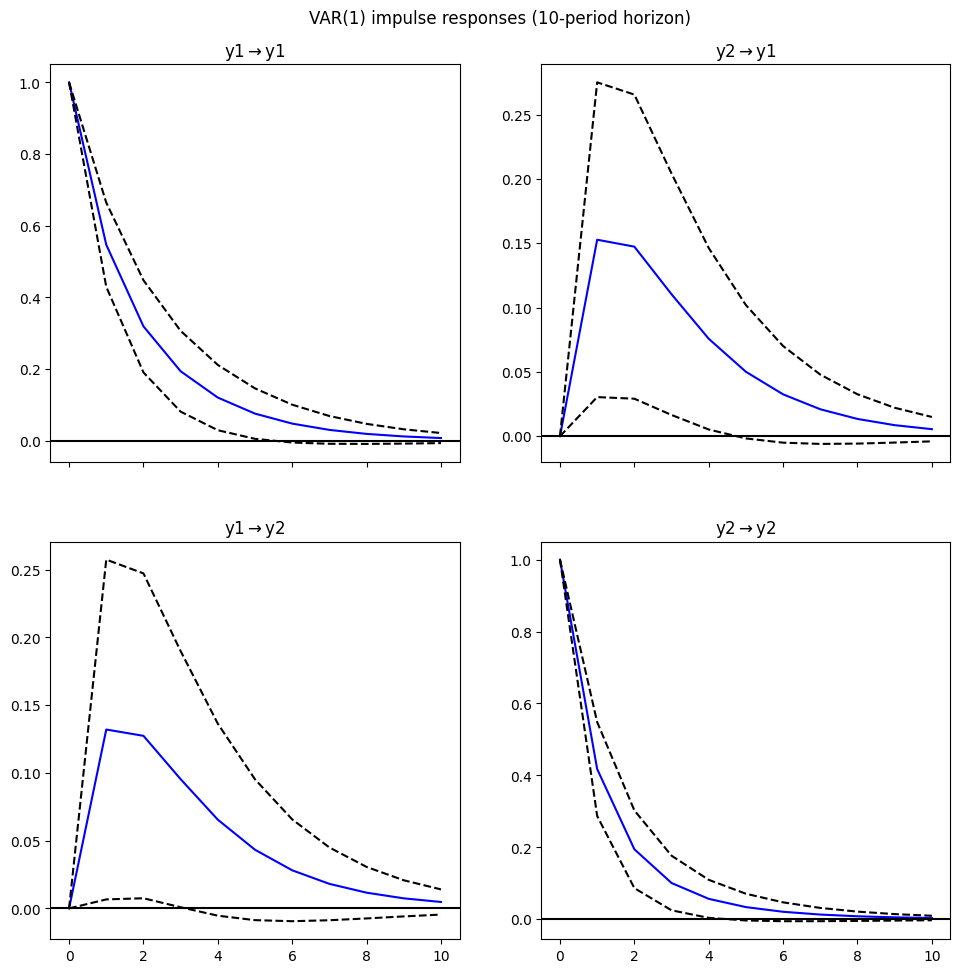

In [50]:
irf = var_res.irf(10)
irf.plot(orth=False)
plt.suptitle('VAR(1) impulse responses (10-period horizon)')
plt.show()


Because the system is stable, every response decays back toward zero rather than exploding.

## 2.5 Forecast error variance decomposition

FEVD for y1
           y1        y2
0    1.000000  0.000000
1    0.963022  0.036978
2    0.944642  0.055358
3    0.937683  0.062317
4    0.935250  0.064750
5    0.934428  0.065572
6    0.934154  0.065846
7    0.934063  0.065937
8    0.934033  0.065967
9    0.934023  0.065977

FEVD for y2
           y1        y2
0    0.163742  0.836258
1    0.187968  0.812032
2    0.196956  0.803044
3    0.200039  0.799961
4    0.201070  0.798930
5    0.201412  0.798588
6    0.201525  0.798475
7    0.201563  0.798437
8    0.201575  0.798425
9    0.201579  0.798421


None


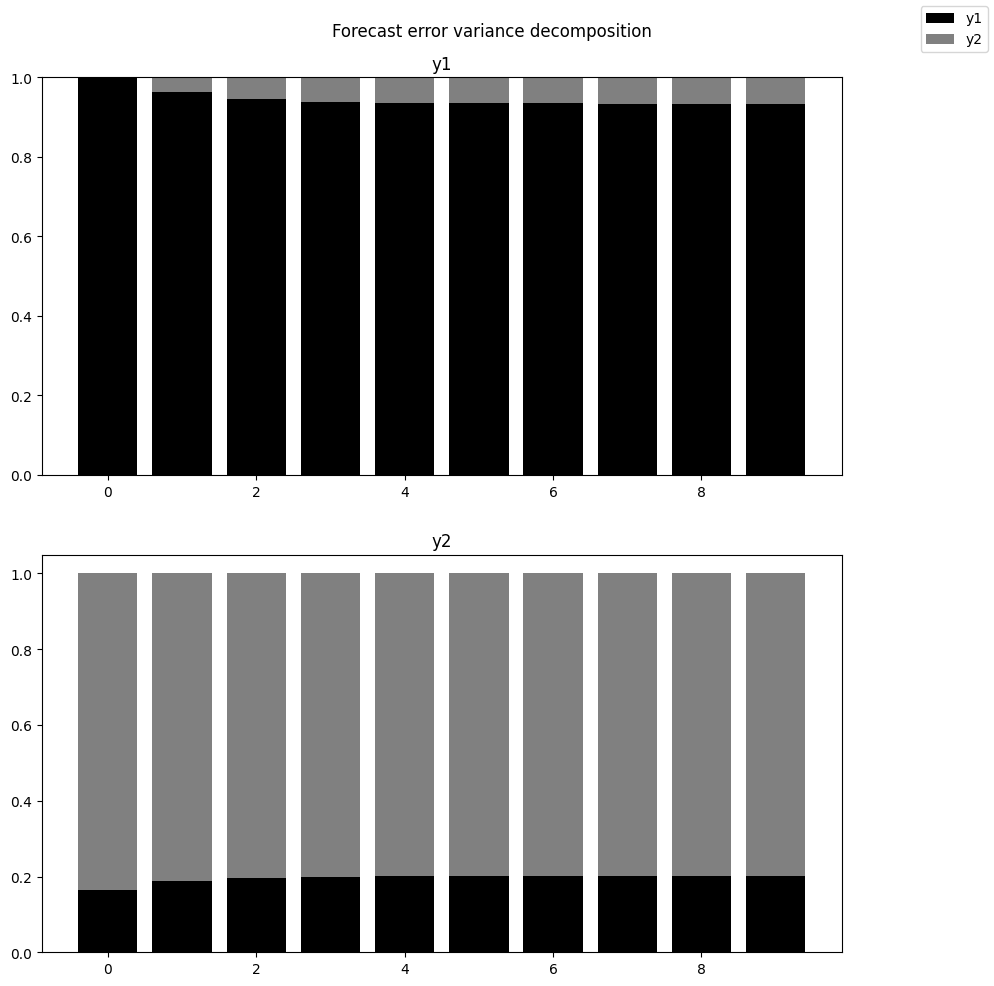

In [14]:
fevd = var_res.fevd(10)
print(fevd.summary())

fevd.plot()
plt.suptitle('Forecast error variance decomposition')
plt.show()


The FEVD splits the forecast-error variance of each variable, at each horizon, into the share attributable to each of the two shocks. At horizon 1 a variable's error variance is driven mostly by its own shock; as the horizon grows the cross-variable share typically increases because the dynamic feedback in `A` has more time to operate.

## 2.6 Repeat steps 1–4 adding an intercept

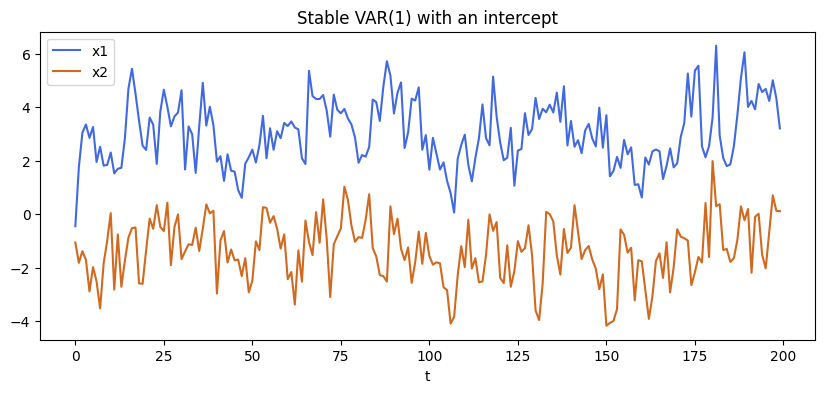

Theoretical unconditional mean: [ 3.57142857 -1.07142857]
Sample mean of the simulated data: [ 3.02266678 -1.36404964]


In [56]:
c_var = np.array([2.0, -1.0])  

x_var_c = np.zeros((T, 2))
x_var_c[0] = eps[0]
for t in range(1, T):
    x_var_c[t] = c_var + A_var @ x_var_c[t - 1] + eps[t]

plt.plot(x_var_c[:, 0], label='x1', color='royalblue')
plt.plot(x_var_c[:, 1], label='x2', color='chocolate')
plt.title('Stable VAR(1) with an intercept')
plt.xlabel('t')
plt.legend()
plt.show()

mean_theoretical = np.linalg.inv(np.eye(2) - A_var) @ c_var
print(f"Theoretical unconditional mean: {mean_theoretical}")
print(f"Sample mean of the simulated data: {x_var_c.mean(axis=0)}")


In [57]:
var_model_c = VAR(x_var_c)
var_res_c = var_model_c.fit(1)     
print(var_res_c.summary())

print("\nTrue intercept   =", c_var)
print("Estimated intercept =", var_res_c.intercept)
print("\nTrue A =\n", A_var)
print("Estimated A =\n", var_res_c.coefs[0])


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 19, Sep, 2026
Time:                     09:57:30
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                -0.00495842
Nobs:                     199.000    HQIC:                -0.0640665
Log likelihood:          -548.364    FPE:                   0.901000
AIC:                    -0.104254    Det(Omega_mle):        0.874437
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         1.644188         0.229608            7.161           0.000
L1.y1         0.534167         0.058439            9.141           0.000
L1.y2         0.159094         0.062295            2.554           0.011

Results for equation 

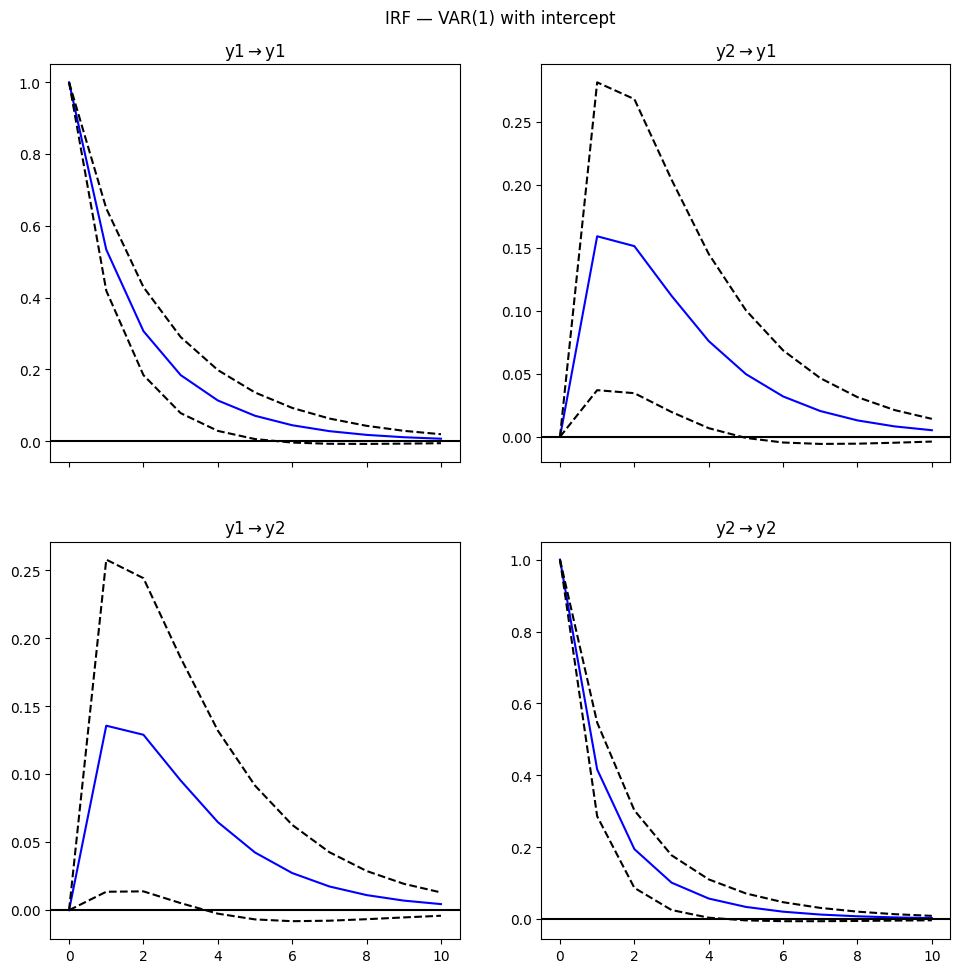

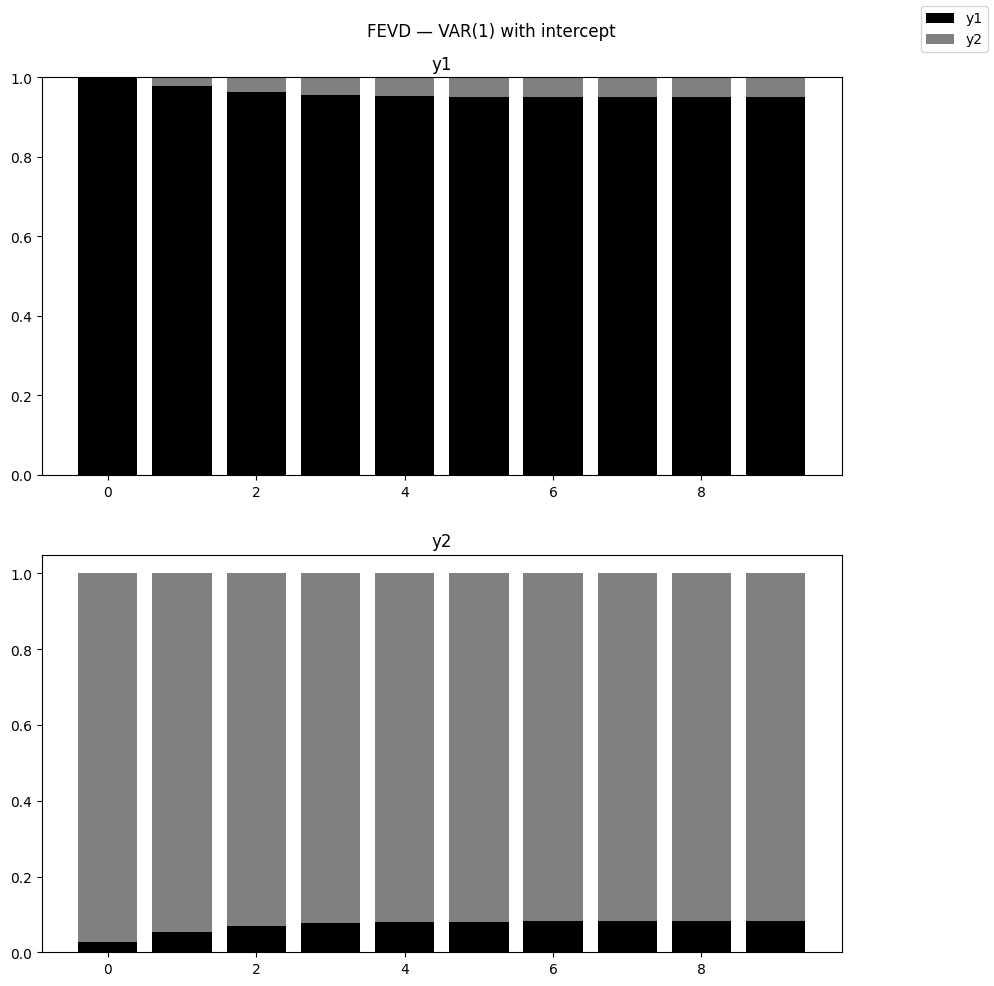

In [53]:
irf_c = var_res_c.irf(10)
irf_c.plot(orth=False)
plt.suptitle('IRF — VAR(1) with intercept')
plt.show()

fevd_c = var_res_c.fevd(10)
fevd_c.plot()
plt.suptitle('FEVD — VAR(1) with intercept')
plt.show()


the estimated slope matrix, the IRFs and the FEVD are essentially the same as without the intercept, because those objects are about how deviations from the mean propagate, not about the mean itself. 

# Assignment 3 — SVAR(1)

The structural system given is

$$x_t = -a_{10}\,y_t + a_{11}x_{t-1} + a_{12}y_{t-1} + u_t$$
$$y_t = -a_{20}\,x_t + a_{21}x_{t-1} + a_{22}y_{t-1} + v_t$$

with the identifying restriction that either $a_{10}=0$ or $a_{20}=0$  In
matrix form,

$$\Gamma_0\, x_t = A_1\, x_{t-1} + \begin{pmatrix}u_t\\ v_t\end{pmatrix}, \qquad
\Gamma_0 = \begin{pmatrix}1 & a_{10}\\ a_{20} & 1\end{pmatrix}, \qquad
A_1 = \begin{pmatrix}a_{11} & a_{12}\\ a_{21} & a_{22}\end{pmatrix}$$

We impose $a_{10}=0$: $x$ is not affected  by $y$, but $y$ is affected
 by $x$. This makes $\Gamma_0$ lower-triangular

## 3.1 Build a stable structural matrix

In [60]:
a10 = 0.0        
a20 = 0.5       
a11, a12 = 0.5, -0.2
a21, a22 = -0.1, 0.4

Gamma0 = np.array([[1, a10],
                    [a20, 1]])
A1 = np.array([[a11, a12],
               [a21, a22]])

A_reduced = np.linalg.inv(Gamma0) @ A1
eigvals_svar = np.linalg.eig(A_reduced)[0]

print("Gamma0 =\n", Gamma0)
print("A1 =\n", A1)
print("Reduced-form A =\n", A_reduced)
print(f"\nEigenvalues: {eigvals_svar}, moduli: {np.abs(eigvals_svar)}")


Gamma0 =
 [[1.  0. ]
 [0.5 1. ]]
A1 =
 [[ 0.5 -0.2]
 [-0.1  0.4]]
Reduced-form A =
 [[ 0.5  -0.2 ]
 [-0.35  0.5 ]]

Eigenvalues: [0.76457513 0.23542487], moduli: [0.76457513 0.23542487]


## 3.2 Simulate a dataset in line with A

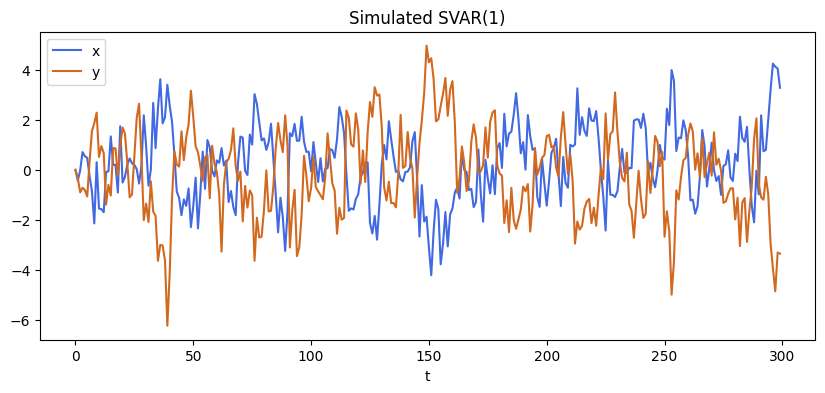

In [65]:
T = 300
u = np.random.normal(0, 1, T)
v = np.random.normal(0, 1, T)

x_s = np.zeros(T)
y_s = np.zeros(T)

for t in range(1, T):
    x_s[t] = a11 * x_s[t - 1] + a12 * y_s[t - 1] + u[t]
    y_s[t] = -a20 * x_s[t] + a21 * x_s[t - 1] + a22 * y_s[t - 1] + v[t]

data_svar = np.column_stack([x_s, y_s])

plt.plot(x_s, label='x', color='royalblue')
plt.plot(y_s, label='y', color='chocolate')
plt.title('Simulated SVAR(1)')
plt.xlabel('t')
plt.legend()
plt.show()


## 3.3 Estimate the SVAR model and report the results

In [66]:
A_restr = np.array([[1, 0],
                     ['E', 1]])
B_restr = np.array([['E', 0],
                     [0, 'E']])

svar_model = SVAR(data_svar, svar_type='AB', A=A_restr, B=B_restr)
svar_res = svar_model.fit(maxiter=10000, maxfun=10000)
svar_res.k_exog_user = 0
print(svar_res.summary())

print("\nTrue a20 =", a20, "  Estimated (Gamma0[1,0]) =", svar_res.A[1, 0])
print("True A1 =\n", A1)
print("Estimated reduced-form coefs =\n", svar_res.coefs)


  Summary of Regression Results   
Model:                        SVAR
Method:                        OLS
Date:           Sat, 19, Sep, 2026
Time:                     10:07:41
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0572905
Nobs:                     299.000    HQIC:                 0.0127549
Log likelihood:          -839.989    FPE:                   0.983179
AIC:                   -0.0169659    Det(Omega_mle):        0.963742
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.091384         0.058335            1.567           0.117
L1.y1         0.437775         0.062168            7.042           0.000
L1.y2        -0.297746         0.052268           -5.696           0.000

Results for equation 

## 3.4 Impulse-response plot

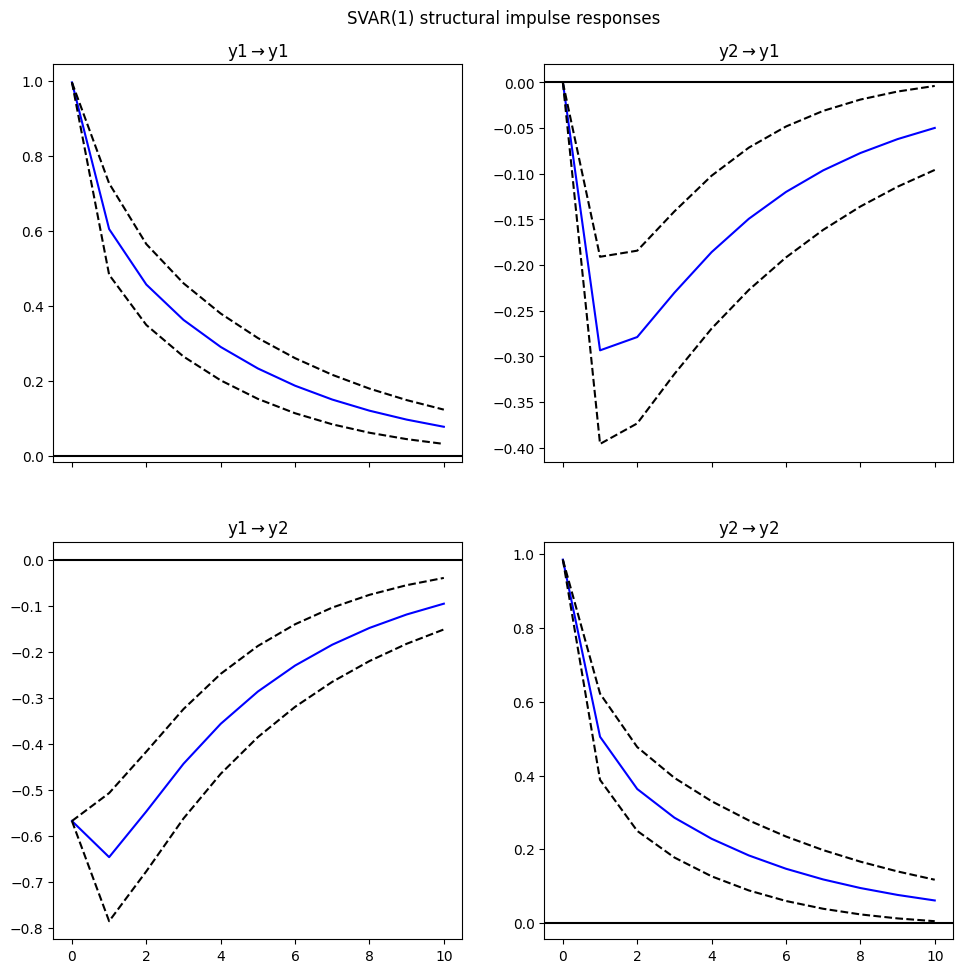

In [67]:
svar_irf = svar_res.irf(10)
svar_irf.plot()
plt.suptitle('SVAR(1) structural impulse responses')
plt.show()


## 3.5 Forecast error variance decomposition

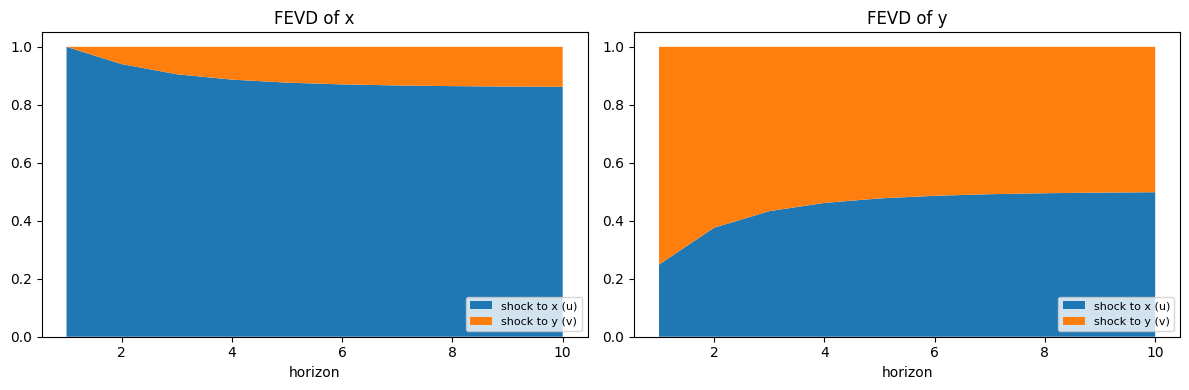

In [68]:
def structural_fevd(res, horizon):
    k = res.neqs
    A1 = res.coefs[0]                                
    theta1 = np.linalg.inv(res.A) @ res.B            
    thetas = [theta1]
    for h in range(1, horizon):
        thetas.append(np.linalg.matrix_power(A1, h) @ theta1)

    mse = np.zeros((k, k))
    fevd_out = np.zeros((horizon, k, k))   
    for h in range(horizon):
        mse += thetas[h] @ thetas[h].T
        for i in range(k):
            for j in range(k):
                contrib = sum(thetas[s][i, j] ** 2 for s in range(h + 1))
                fevd_out[h, i, j] = contrib / mse[i, i]
    return fevd_out

fevd_s = structural_fevd(svar_res, 10)

var_names = ['x', 'y']
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    axs[i].stackplot(range(1, 11), fevd_s[:, i, 0], fevd_s[:, i, 1],
                      labels=['shock to x (u)', 'shock to y (v)'])
    axs[i].set_title(f'FEVD of {var_names[i]}')
    axs[i].set_xlabel('horizon')
    axs[i].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


Because $x$ does not respond to $y$ contemporaneously, 100% of $x$'s one-period-ahead forecast error variance is attributable to its own shock $u$. $y$, in contrast, is hit immediately by both shocks, so even at horizon 1 some share of its variance is due to $u$. As the horizon grows, feedback through the lag matrix $A_1$ lets $y$'s history also influence $x$'s errors, so $x$'s own-shock share typically falls below 100%.

# Assignment 4 — Negatively correlated VAR/SVAR, and a real-data application

## 4.1 A stable, negatively correlated structural system

Reuse the recursive SVAR(1) structure from Assignment 3, but now set the sign of
the contemporaneous link so that $x$ and $y$ move in opposite directions.

In [69]:
a10_n = 0.0
a20_n = 0.5        
a11_n, a12_n = 0.5, -0.2
a21_n, a22_n = -0.1, 0.4

Gamma0_n = np.array([[1, a10_n], [a20_n, 1]])
A1_n = np.array([[a11_n, a12_n], [a21_n, a22_n]])
A_reduced_n = np.linalg.inv(Gamma0_n) @ A1_n

print("Reduced-form A =\n", A_reduced_n)


Reduced-form A =
 [[ 0.5  -0.2 ]
 [-0.35  0.5 ]]


## 4.2 Check stability

In [70]:
eigvals_n = np.linalg.eig(A_reduced_n)[0]
print(f"Eigenvalues: {eigvals_n}")
print(f"Moduli: {np.abs(eigvals_n)}")



Eigenvalues: [0.76457513 0.23542487]
Moduli: [0.76457513 0.23542487]


## 4.3 Visualize and discuss

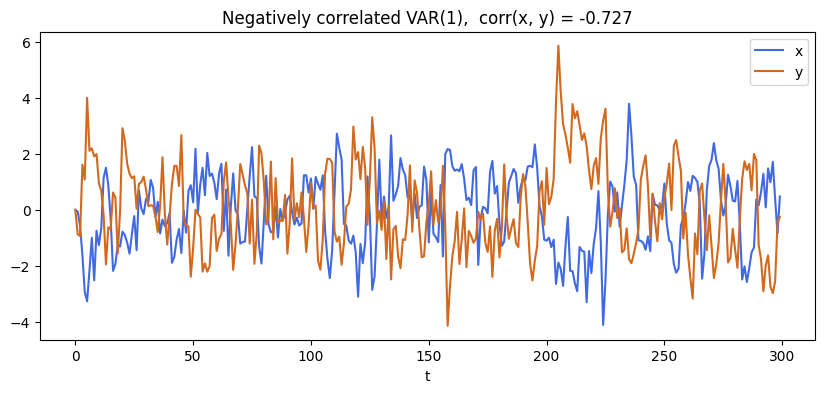

In [71]:
T = 300
u_n = np.random.normal(0, 1, T)
v_n = np.random.normal(0, 1, T)

x_n = np.zeros(T)
y_n = np.zeros(T)
for t in range(1, T):
    x_n[t] = a11_n * x_n[t - 1] + a12_n * y_n[t - 1] + u_n[t]
    y_n[t] = -a20_n * x_n[t] + a21_n * x_n[t - 1] + a22_n * y_n[t - 1] + v_n[t]

data_n = np.column_stack([x_n, y_n])
corr_n = np.corrcoef(x_n, y_n)[0, 1]

plt.plot(x_n, label='x', color='royalblue')
plt.plot(y_n, label='y', color='chocolate')
plt.title(f'Negatively correlated VAR(1),  corr(x, y) = {corr_n:.3f}')
plt.xlabel('t')
plt.legend()
plt.show()


The two series are stable but visibly move opposite each other: when x rises, the negative  coefficient pulls y down in the same period, and the negative lag coefficients $a_{12}, a_{21}$ reinforce that opposition one period later. 

## 4.4 Estimate a VAR model and compare true vs. estimated coefficients

In [23]:
var_model_n = VAR(data_n)
var_res_n = var_model_n.fit(1)
print(var_res_n.summary())

print("\nTrue reduced-form A =\n", A_reduced_n)
print("Estimated A =\n", var_res_n.coefs[0])
print("\nElement-wise estimation error =\n", var_res_n.coefs[0] - A_reduced_n)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 18, Sep, 2026
Time:                     09:21:51
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0247884
Nobs:                     299.000    HQIC:                -0.0197472
Log likelihood:          -835.130    FPE:                   0.951737
AIC:                   -0.0494680    Det(Omega_mle):        0.932922
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.048182         0.058329            0.826           0.409
L1.y1         0.477347         0.062076            7.690           0.000
L1.y2        -0.293362         0.053635           -5.470           0.000

Results for equation 

## 4.5 Estimate an SVAR model and compare true vs. estimated coefficients

In [24]:
A_restr_n = np.array([[1, 0], ['E', 1]])
B_restr_n = np.array([['E', 0], [0, 'E']])

svar_model_n = SVAR(data_n, svar_type='AB', A=A_restr_n, B=B_restr_n)
svar_res_n = svar_model_n.fit(maxiter=10000, maxfun=10000)
svar_res_n.k_exog_user = 0

print("True Gamma0 =\n", Gamma0_n)
print("Estimated Gamma0 (res.A) =\n", svar_res_n.A)
print("\nTrue a20 =", a20_n, " Estimated a20 =", svar_res_n.A[1, 0])
print("\nTrue A1 (structural lag matrix) =\n", A1_n)
print("Estimated reduced-form coefs =\n", svar_res_n.coefs)


True Gamma0 =
 [[1.  0. ]
 [0.5 1. ]]
Estimated Gamma0 (res.A) =
 [[1.         0.        ]
 [0.56184892 1.        ]]

True a20 = 0.5  Estimated a20 = 0.5618489164757333

True A1 (structural lag matrix) =
 [[ 0.5 -0.2]
 [-0.1  0.4]]
Estimated reduced-form coefs =
 [[[ 0.47734659 -0.29336187]
  [-0.35723389  0.51309751]]]


Both the VAR and SVAR estimates should recover coefficients close to their true counterparts 

## 4.6 A real-data application

Based on the Phillips-curve relationship between inflation and unemployment build our model


/var/folders/4c/s5j521nd21v6thklgmvkv5r40000gn/T/ipykernel_80451/2378510894.py:2: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  macro.index = pd.PeriodIndex(year=macro.year.astype(int), quarter=macro.quarter.astype(int), freq='Q')


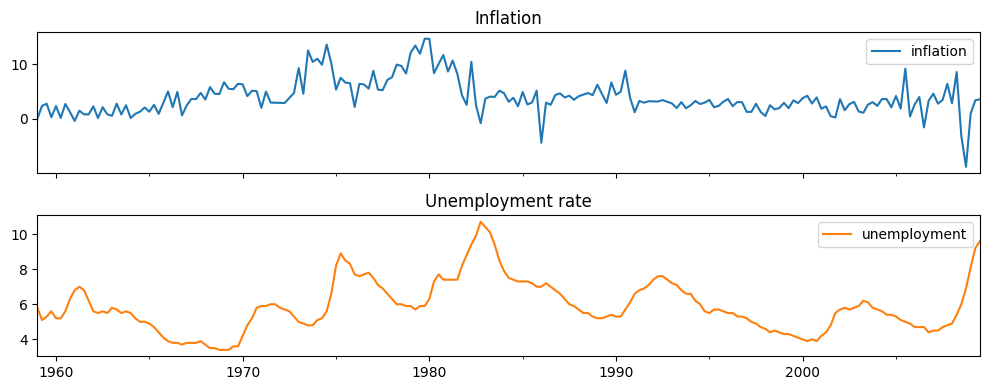

Sample correlation: 0.065


In [61]:
macro = sm.datasets.macrodata.load_pandas().data
macro.index = pd.PeriodIndex(year=macro.year.astype(int), quarter=macro.quarter.astype(int), freq='Q')

real_data = macro[['infl', 'unemp']].dropna()
real_data.columns = ['inflation', 'unemployment']
real_data.plot(subplots=True, title=['Inflation', 'Unemployment rate'])
plt.tight_layout()
plt.show()

print(f"Sample correlation: {real_data['inflation'].corr(real_data['unemployment']):.3f}")


In [63]:
real_var = VAR(real_data)
lag_order = real_var.select_order(maxlags=8)
print(lag_order.summary())

real_res = real_var.fit(maxlags=8, ic='aic')
print(real_res.summary())


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       3.167       3.201       23.74       3.181
1     -0.2977     -0.1970      0.7425     -0.2569
2      -1.105     -0.9374      0.3311      -1.037
3      -1.191    -0.9563*      0.3038      -1.096
4      -1.226     -0.9235      0.2936     -1.103*
5     -1.241*     -0.8720     0.2891*      -1.092
6      -1.231     -0.7951      0.2920      -1.055
7      -1.220     -0.7169      0.2953      -1.017
8      -1.204     -0.6334      0.3002     -0.9731
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 19, Sep, 2026
Time:                     10:06:37
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  -0.838048
Nobs:                     198.000    

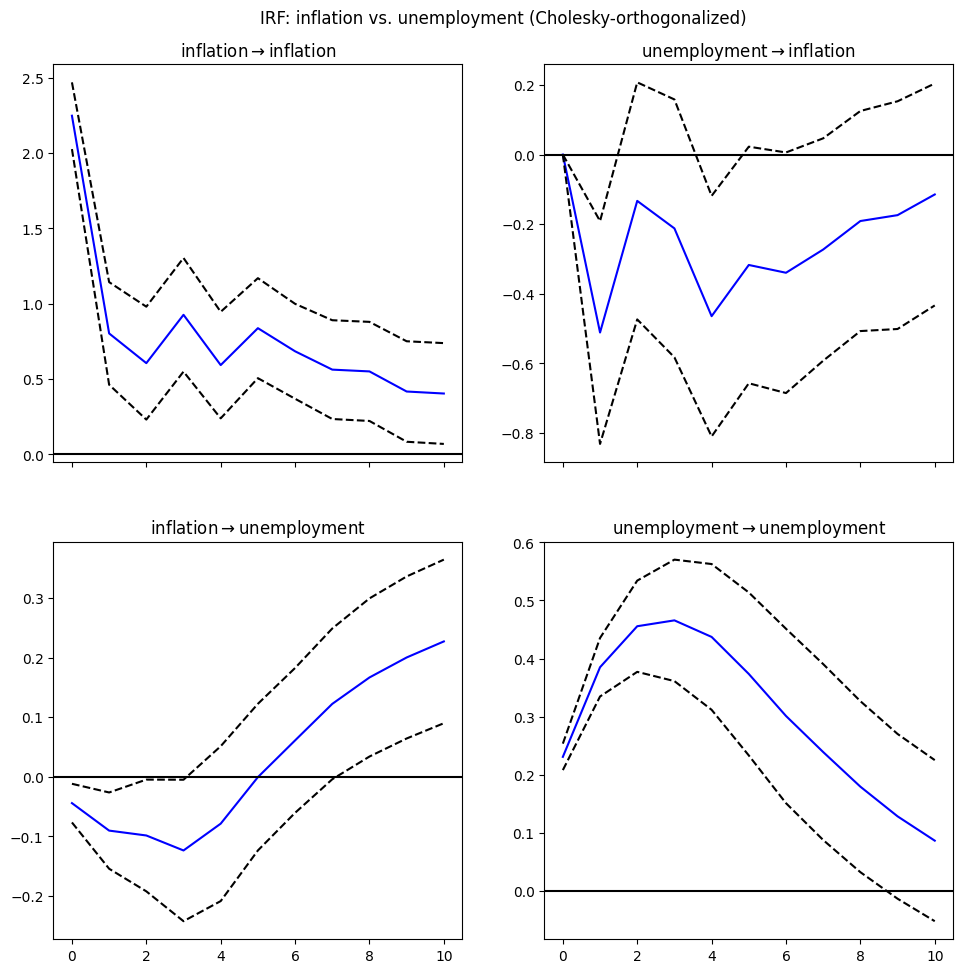

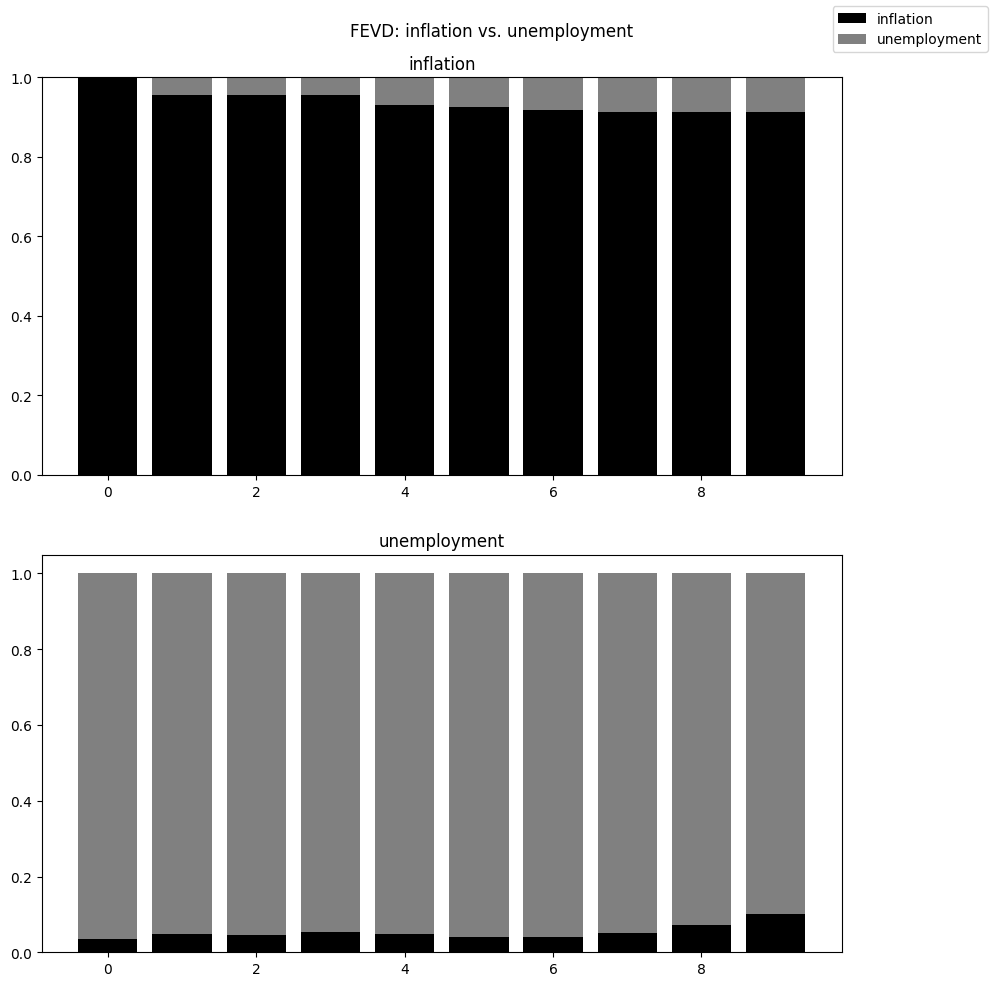

In [64]:
real_irf = real_res.irf(10)
real_irf.plot(orth=True)
plt.suptitle('IRF: inflation vs. unemployment (Cholesky-orthogonalized)')
plt.show()

real_fevd = real_res.fevd(10)
real_fevd.plot()
plt.suptitle('FEVD: inflation vs. unemployment')
plt.show()


The Phillips-curve suggests a negative relationship between inflation and unemployment. 